This notebook gives you the essentials to work with PyJAGS. If you use a Windows machine, you have to work in e.g. a virtual machine or use Google Colab, in which you can install JAGS and PyJAGS with the code below:

In [1]:
!apt install jags
!pip install pyjags




jags is already the newest version (4.3.0-3).
0 upgraded, 0 newly installed, 0 to remove and 6 not upgraded.


Import preliminaries.

In [3]:
#Здесь импортируются библиотеки и настраиваются параметры для построения графиков
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as st
import pyjags as pj

print('Using PyJAGS v{:s}'.format(pj.__version__))

from matplotlib import rc
# rc('font',**{'family':'serif','serif':['Palatino']})
rc('text', usetex=False)

plt.rc('axes', titlesize=30)        # fontsize of the axes title
plt.rc('axes', labelsize=24)        # fontsize of the x and y labels
plt.rc('xtick', labelsize=18)       # fontsize of the tick labels
plt.rc('ytick', labelsize=18)       # fontsize of the tick labels
plt.rc('legend', fontsize=12)       # legend fontsize
plt.rc('figure', titlesize=36)      # fontsize of the figure title

Using PyJAGS v1.3.8


We'll use JAGS to infer a difference $\delta$ in coin flip probabilities between two coins, using the observations we have for both. Our generative model is:

$$
\begin{equation}
  \begin{split}
    \theta_j \mid \omega, \kappa &\sim \text{beta}(\omega(\kappa-2)+1, (1-\omega)(\kappa-2)+1)\\
    y_{ij} \mid \theta_j &\sim \text{Bernoulli}(\theta_j)\\
    \delta & = \theta_2 - \theta_1
  \end{split}
\end{equation}
$$ 

where $j=1,2$ and $i=1, \ldots, n_j$, with $n_1$ and $n_2$ the total coin flips for the first and second coin, respectively.

As prior beliefs we say we expect the probabilities to be around fair: $\omega=0.5$, but we allow some variability with $\kappa=5$.

In practice, we would run such a model on actual data we observe from some experiment. For now, we'll simulate data to understand the procedure:

In [5]:
# Number of observations
n1, n2 = 12, 18 #количество подбрасываний первой и второй монеты.

# In reality, we would not know the true values and would only be able to learn their posterior distribution!
theta1, theta2 = 0.6, 0.7  # истинные вероятности выпадения "орла". (в реальности они неизвестны)

# Observations
y1 = np.random.binomial(n=1, p=theta1, size=n1) # массивы с результатами подбрасываний монет, смоделированные с помощью биномиального распределения
y2 = np.random.binomial(n=1, p=theta2, size=n2)  #, смоделированные с помощью биномиального распределения

In [7]:
# Our JAGS code is just a string, optionally in a separate file. #В этой части задается модель для JAGS.
jags_code = '''
model {

  # transform mean and concentration of beta distribution into familiar a and b:
  a <- omega*(kappa - 2) + 1
  b <- (1 - omega)*(kappa - 2) + 1
  # Преобразование среднего и концентрации бета-распределения в стандартные параметры:
  a <- omega*(kappa - 2) + 1
  b <- (1 - omega)*(kappa - 2) + 1

  # Prior: Вероятности выпадения "орла" моделируются через бета-распределение
  for (i in 1:2) {
    theta[i] ~ dbeta(a,b)
  }

  # Likelihood: Подбрасывания моделируются через распределение Бернулли.
  for (i in 1:n1) {
    y1[i] ~ dbern(theta[1])
  }

  #Вычисляется разница вероятностей между двумя монетами.
  for (i in 1:n2) {
    y2[i] ~ dbern(theta[2])
  }
  delta <- theta[2] - theta[1]

}
'''

# Data consists of observations and hyperparameters that describe our priors. Создается словарь data с данными для модели
data = dict(y1=y1, y2=y2, n1=n1, n2=n2, omega=0.5, kappa=10)

# How long we sample количество итераций MCMC
niter = 50000
# How many parallel sampling runs количество параллельных цепей.
chains = 4

# Construct the PyJAGS model
m = pj.Model(jags_code, data=data, chains=chains)
# Do MCMC
samples = m.sample(niter, vars=['theta', 'delta'])
# Note, samples is a dictionary, with the elements of 'vars' as keys.
print('Sampling complete.')

sampling: iterations 200000 of 200000, elapsed 0:00:00, remaining 0:00:00
Sampling complete.


First, let's check for convergence:


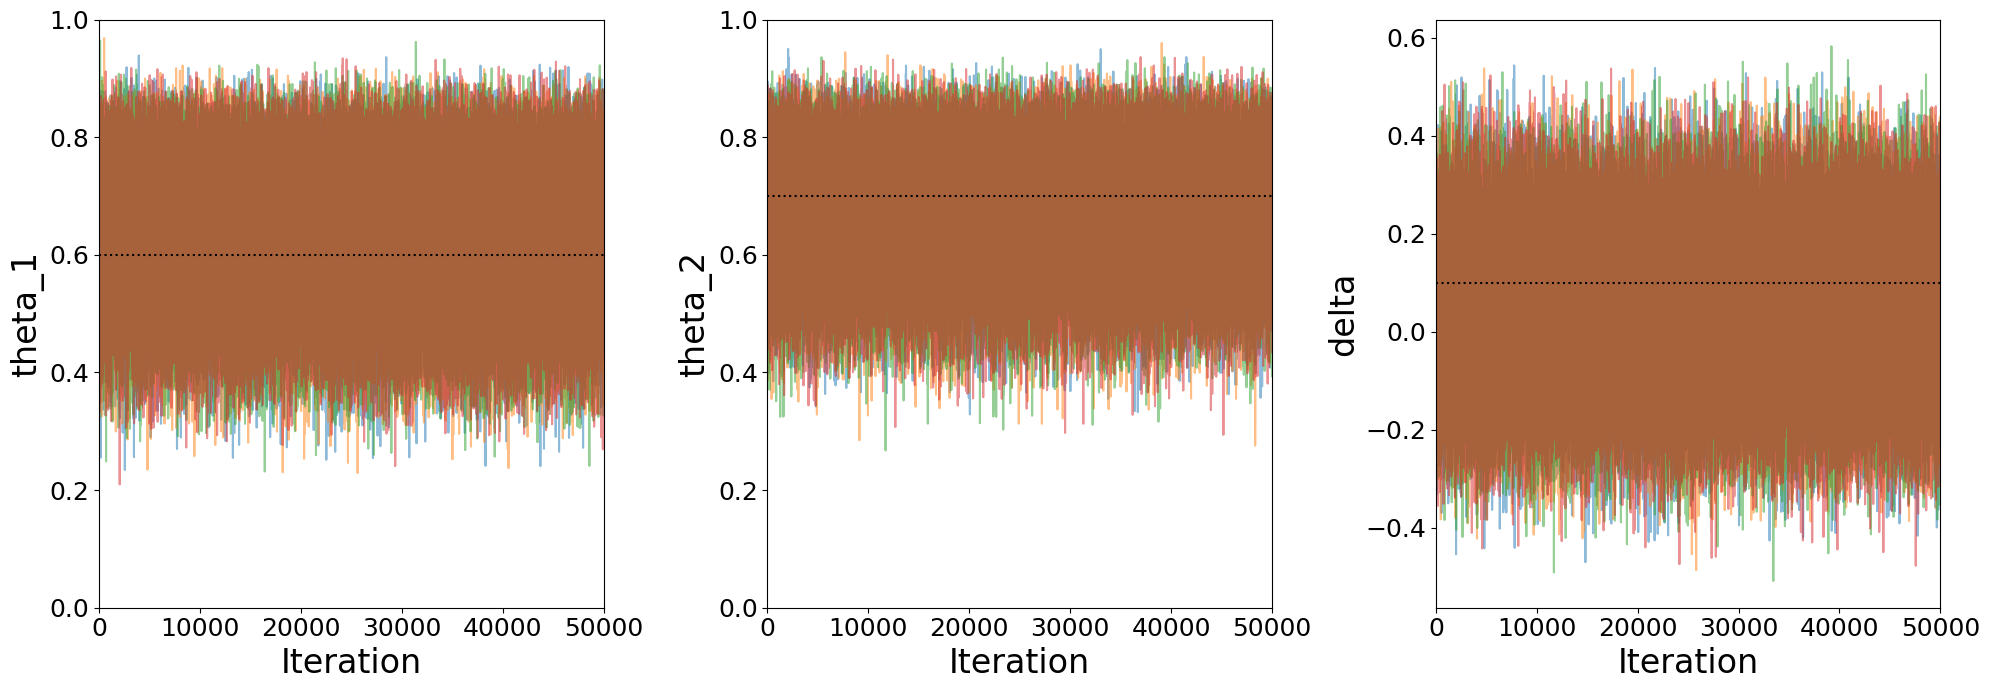

In [9]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(20,7), sharex=True)

parnames = ['theta_1', 'theta_2', 'delta'] #Строятся графики для параметров θ1θ1​, θ2θ2​ и δδ.

theta1_samples_chains = samples['theta'][0,:,:]
theta2_samples_chains = samples['theta'][1,:,:]
delta_samples_chains = samples['delta']

for i, samples_chains in enumerate([theta1_samples_chains,
                                    theta2_samples_chains,
                                    delta_samples_chains]):
  axes[i].plot(np.squeeze(samples_chains), alpha=0.5)
  if i < 2:
    axes[i].set_ylim([0, 1])
  axes[i].set_xlim([0, niter])
  axes[i].set_xlabel('Iteration')
  axes[i].set_ylabel(parnames[i])
axes[0].axhline(y=theta1, ls=':', c='k') #Горизонтальные линии показывают истинные значения параметров.
axes[1].axhline(y=theta2, ls=':', c='k')
axes[2].axhline(y=theta2-theta1, ls=':', c='k')
plt.tight_layout() #Проверяется сходимость цепей MCMC

No way to visually discern the different chains, so it seems reasonable to assume the chains have converged! Let's plot the results
"Нет способа визуально различить разные цепи, так что кажется разумным предположить, что они сошлись! Давайте построим результаты."

Text(0.5, 0.98, 'Difference in coin flips')

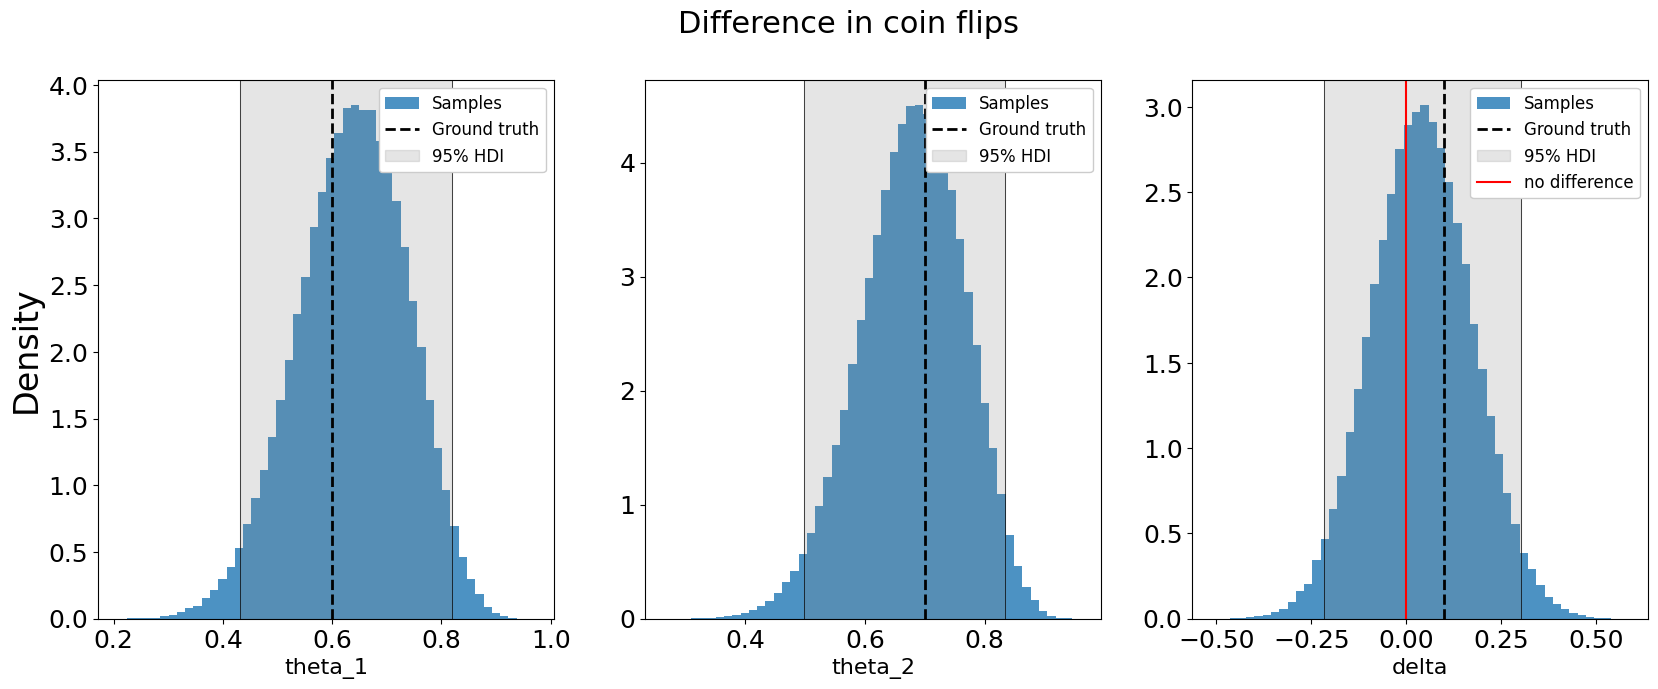

In [11]:
#Функция hdi_intv вычисляет 95%-й доверительный интервал (HDI).
def hdi_intv(samples, hdi=0.95):
  # This helper function computes the 95% HDI
  t = niter*chains
  x = np.sort(samples)
  hdi_lb = x[int((1.0 - hdi)/2 * t)]
  hdi_ub = x[int((1.0 + hdi)/2 * t)]
  return hdi_lb, hdi_ub

#Строятся гистограммы выборок и отображается 95%-й доверительный интервал.
parnames = ['theta_1', 'theta_2', 'delta']
# True values that we used for simulation
ground_truth = [theta1, theta2, (theta2-theta1)]

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(20,7))
# use flatten() to combine all chains
theta1_samples = samples['theta'][0,:,:].flatten()
theta2_samples = samples['theta'][1,:,:].flatten()
delta_samples = samples['delta'].flatten()

for i, x in enumerate([theta1_samples, theta2_samples, delta_samples]):  
  # Plot histogram of samples, normalize to a density.
  axes[i].hist(x, bins=50, histtype='stepfilled', alpha=0.8, density=True, label='Samples')
  axes[i].set_xlabel('{:s}'.format(parnames[i]), fontsize=16)
  axes[i].axvline(x=ground_truth[i], ls='--', color='k', lw=2, label='Ground truth')

  # Plot 95% HDI
  hdi_lb, hdi_ub = hdi_intv(x) 
  axes[i].axvspan(hdi_lb, hdi_ub, color='grey', alpha=0.2, label='95% HDI')
  axes[i].axvline(x=hdi_lb, lw=0.5, color='k')
  axes[i].axvline(x=hdi_ub, lw=0.5, color='k')

# Zero difference, i.e. the probabilities are equal Проверяется, попадает ли δ=0δ=0 в HDI
axes[2].axvline(x=0.0, ls='-', lw=1.5, color='red', label='no difference')
axes[0].set_ylabel('Density')
for ax in axes:
  ax.legend(framealpha=1.0)

plt.suptitle('Difference in coin flips', fontsize=22)

For the standard settings in this notebook, it will be hard to find a difference - in most cases, the $\delta=0$ will be in the 95% HDI. But if we had more data, that would change - you can rerun the example with higher values for $n_1$ and $n_2$ and see the difference.

"При стандартных настройках будет сложно обнаружить разницу — в большинстве случаев δ=0δ=0 попадет в 95%-й HDI. Но если увеличить количество данных, ситуация изменится.

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=aa206d6c-faf1-4975-9ced-68aa4e3aa145' target="_blank">
 </img>
Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>